<a href="https://colab.research.google.com/github/Phyron-gif/lab-3-feedforward-networks/blob/main/lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


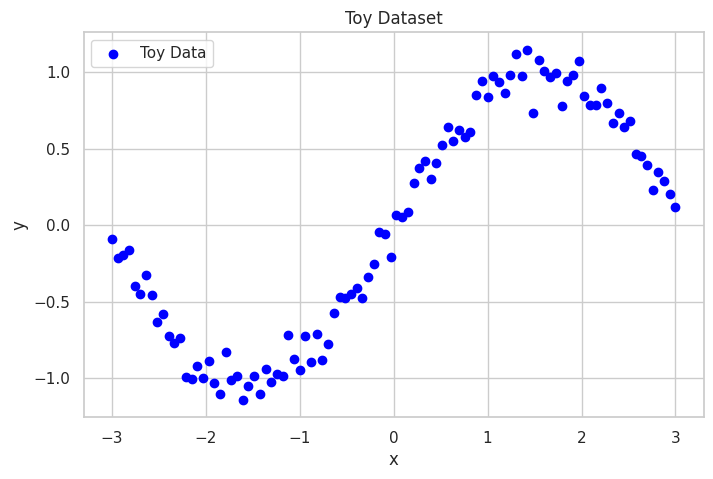

In [ ]:
#toy dataset
import numpy as np
import matplotlib.pyplot as plt

# Generate 100 evenly spaced x-values between -3 and 3
x = np.linspace(-3, 3, 100)

# Generate y-values using the sine function and add Gaussian noise
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)

# Plot the generated data
plt.figure(figsize=(8,5))
plt.scatter(x, y, color='blue', label='Toy Data')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Toy Dataset")
plt.legend()
plt.show()

In [ ]:
# TODO: Initialise w and b to small random values.
w = np.random.randn() * 0.1
b = np.random.randn() * 0.1

In [ ]:
# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:

lr = 0.01
losses = []

for step in range(200):
    y_hat = w * x + b
    loss = np.mean((y_hat - y) ** 2)
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))
    w -= lr * dw
    b -= lr * db
    losses.append(loss)


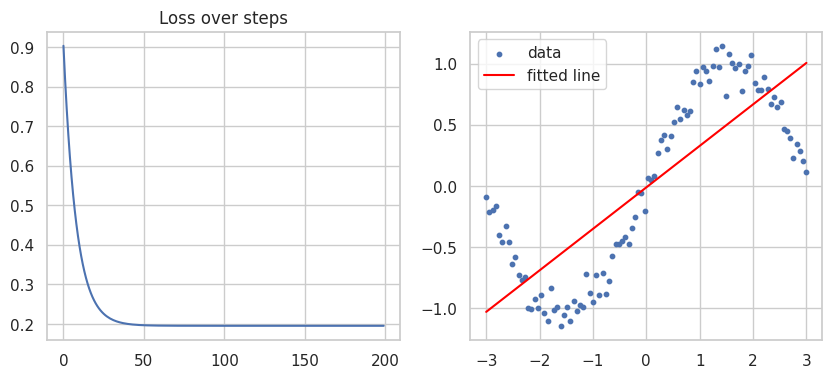

In [ ]:
# TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(losses)
axes[0].set_title("Loss over steps")

axes[1].scatter(x, y, s=10, label="data")
axes[1].plot(x, w * x + b, color="red", label="fitted line")
axes[1].legend()
plt.show()

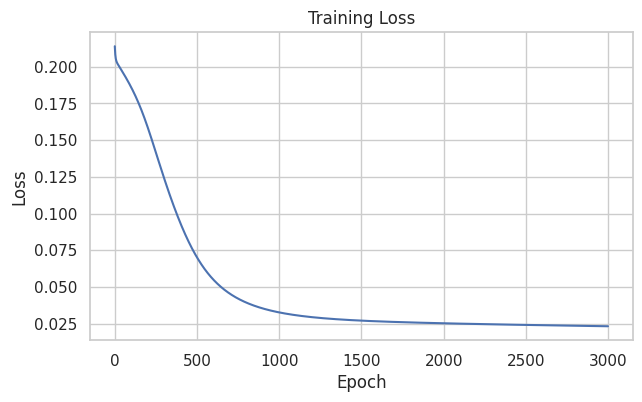

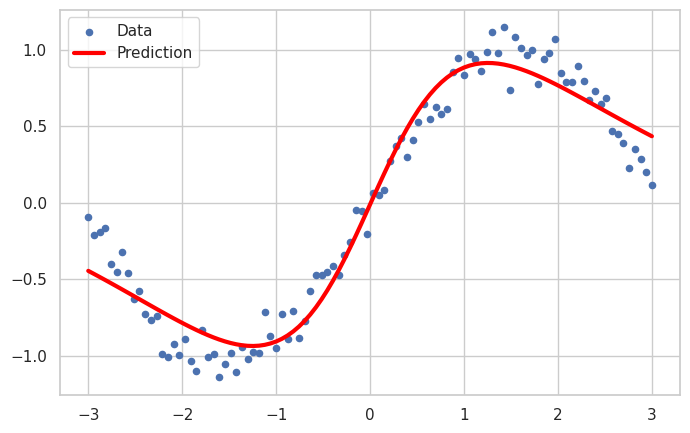

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# Prepare the data
np.random.seed(42)

x = np.linspace(-3, 3, 100).reshape(-1, 1)
y = (np.sin(x) + np.random.normal(0, 0.1, x.shape))


# Initialise parameters
W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros(8)

W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros(1)

lr = 0.01
epochs = 3000

losses = []


# Training loop

for epoch in range(epochs):

    # Forward pass
    z1 = x @ W1 + b1
    h = np.tanh(z1)
    y_hat = h @ W2 + b2

    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)


    # Backward pass

    d_yhat = 2 * (y_hat - y) / len(y)

    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)

    dh = d_yhat @ W2.T

    dz1 = dh * (1 - np.tanh(z1) ** 2)

    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)


    # Gradient Descent

    W2 -= lr * dW2
    b2 -= lr * db2

    W1 -= lr * dW1
    b1 -= lr * db1


# Plot loss

plt.figure(figsize=(7,4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()


# Plot prediction

plt.figure(figsize=(8,5))
plt.scatter(x, y, s=20, label="Data")
plt.plot(x, y_hat, color="red", linewidth=3, label="Prediction")
plt.legend()
plt.show()


Student Readoning
with tanh removed the deep network is no better  than a single neuron network.
Mathematically  the hidden layer is h=xW1​+b1​ and the output layer becomes y^​=hW2​+b2​. expanding we will get y^ = x(W1W2)+(b1W2+b2). now if we define W=W1W2 and b= b1W2+b2 then the entire network simplifies to y^=xW+b which is exactly a single linear layer. Therefore stacking linear layers without a nonlinear activation doesnot increase model's expressive capabiblity.

 **What role did the hidden layer's 8 neurons play in fitting the curve?**

 Each hidden neuron learned a different nonlinear transformation of the input after applying the tanh activation.The output layer then combined the eight activations to approximate the overall sine curve, allowing the network to model a relationship that a single linear neuron could not capture.

 **In one sentence, what is backpropagation?**

 Backpropagation is the algorithm that applies the chain rule to compute the gradient of the loss with respect to every weight and bias in a neural network, enabling gradient descent to update those parameters efficiently.



/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_849/2188629252.py:31: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y) ** 2)
/tmp/ipykernel_849/2188629252.py:40: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ W2.T
/tmp/ipykernel_849/2188629252.py:41: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)
/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


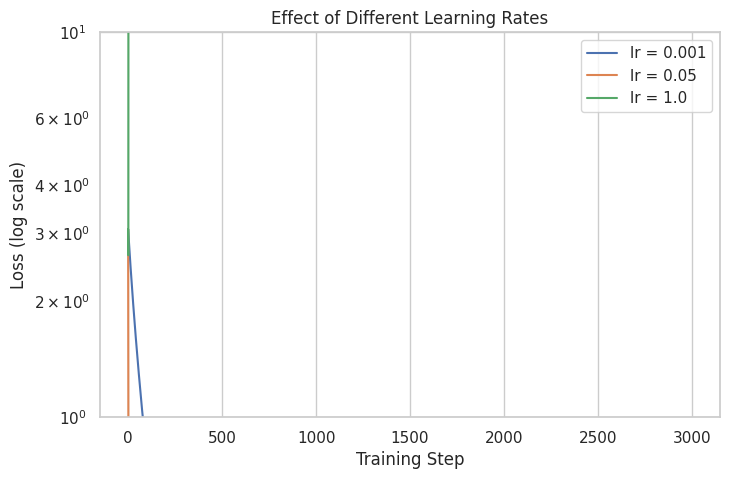

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate the toy dataset
np.random.seed(42)
x = np.linspace(-3, 3, 100).reshape(-1, 1)
y = np.sin(x) + np.random.normal(0, 0.1, x.shape)

# Training function
def train_toy(lr, steps=3000):

    # Reset seed for fair comparison
    np.random.seed(42)

    # Initialise parameters
    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.zeros(8)

    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.zeros(1)

    losses = []

    for _ in range(steps):

        # Forward pass
        z1 = x @ W1 + b1
        h = np.tanh(z1)
        y_hat = h @ W2 + b2

        loss = np.mean((y_hat - y) ** 2)
        losses.append(loss)

        # Backward pass
        d_yhat = 2 * (y_hat - y) / len(y)

        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)

        dh = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)

        dW1 = x.T @ dz1
        db1 = dz1.sum(axis=0)

        # Update parameters
        W2 -= lr * dW2
        b2 -= lr * db2

        W1 -= lr * dW1
        b1 -= lr * db1

    return losses

# Train with three learning rates
loss_small = train_toy(lr=0.001)
loss_medium = train_toy(lr=0.05)
loss_large = train_toy(lr=1.0)

# Plot the loss curves
plt.figure(figsize=(8,5))

plt.plot(loss_small, label="lr = 0.001")
plt.plot(loss_medium, label="lr = 0.05")
plt.plot(loss_large, label="lr = 1.0")

plt.yscale("log")
plt.xlabel("Training Step")
plt.ylabel("Loss (log scale)")
plt.title("Effect of Different Learning Rates")
plt.legend()

plt.show()

**Student Reasoning — Learning Rate**

lr = 0.001: The loss decreases slowly because the parameter updates are very small.

lr = 0.05: The loss decreases quickly and converges smoothly to a low value.

lr = 1.0: The loss oscillates or increases because the updates are too large.

**Why does a too-large learning rate make the loss explode or oscillate instead of just "learning faster"?**

A very large learning rate causes the parameter updates to overshoot the minimum loss repeatedly, preventing the model from converging.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

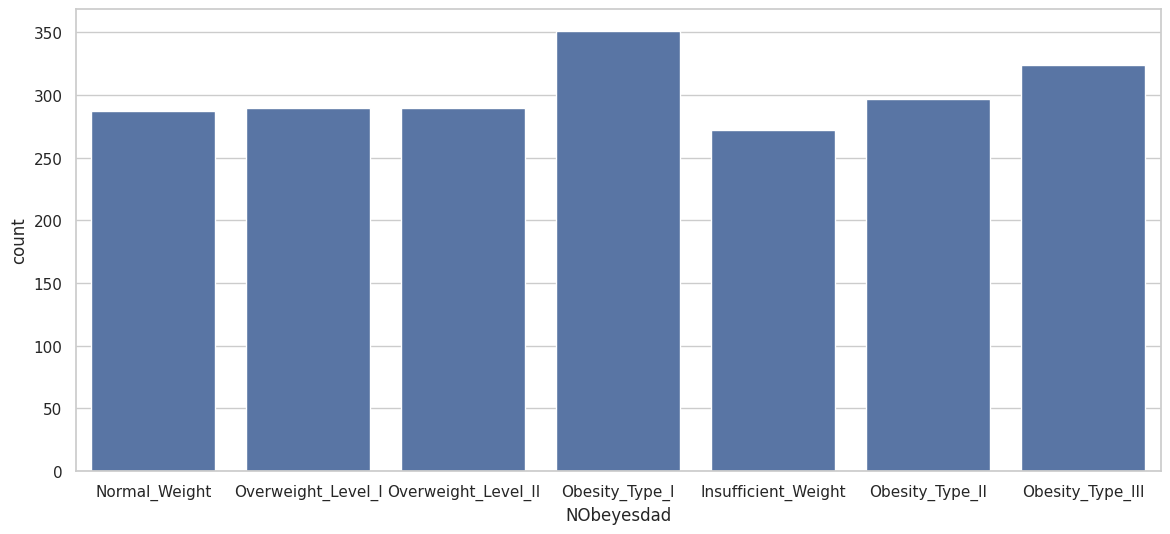

In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt




sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42



OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

obesity=pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv")
obesity.shape
obesity.head()
obesity.info()
obesity.describe()
obesity.isna().sum()
plt.figure(figsize=(14, 6))
sns.countplot(data=obesity, x='NObeyesdad')
value_counts = obesity['NObeyesdad'].value_counts()






In [ ]:
# TODO: Encode categorical columns.
binary_columns = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
for col in binary_columns:
    obesity[col] = obesity[col].map({'yes': 1, 'no': 0})

print(obesity['CAEC'].unique())
print(obesity['CALC'].unique())

from sklearn.preprocessing import OrdinalEncoder
caec_order =['Sometimes', 'Frequently', 'Always', 'no']
calc_order=['no', 'Sometimes', 'Frequently', 'Always']

caec_encoder = OrdinalEncoder(categories=[caec_order])
calc_encoder = OrdinalEncoder(categories=[calc_order])

obesity['CAEC'] = caec_encoder.fit_transform(obesity[['CAEC']])
obesity['CALC'] = calc_encoder.fit_transform(obesity[['CALC']])
#i chose to use ordinal encoding for CAEC and CALC because they have a natural order of frequency, which can be captured by assigning integer values.

nominal_columns = ['Gender', 'MTRANS']
obesity = pd.get_dummies(obesity, columns=nominal_columns, drop_first=True)
# i chhoose to use normal encoding for Gender and MTRANS because they are categorical variables without a natural order,
# and one-hot encoding allows the model to learn separate weights for each category without introducing any ordinal relationships.

#
# TODO (optional but encouraged): engineer a domain feature, e.g. BMI = Weight / Height**2.
BMI = obesity['Weight'] / (obesity['Height'] ** 2)
obesity['BMI'] = BMI

#the bmi feature doesnot leak the target variable, but it is highly correlated with the target variable.


# TODO: Encode the target `NObeyesdad` into integer class labels
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
obesity['NObeyesdad'] = label_encoder.fit_transform(obesity['NObeyesdad'])

# TODO: Scale the numeric features (fit on TRAIN only, in Part 2.3).
X = obesity.drop(columns=['NObeyesdad'])
y = obesity['NObeyesdad']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE)

numeric_columns = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'CAEC', 'CALC', 'BMI']
scaler = StandardScaler()
#I used StandardScaler to scale the numeric features because it standardizes the features by removing the mean and scaling to unit variance,
# which is important for many machine learning algorithms that are sensitive to the scale of input data.

#fitting data on train only
X_train[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])
X_val[numeric_columns] = scaler.transform(X_val[numeric_columns])
X_test[numeric_columns] = scaler.transform(X_test[numeric_columns])

['Sometimes' 'Frequently' 'Always' 'no']
['no' 'Sometimes' 'Frequently' 'Always']


In [ ]:
# TODO: Separate X (features) and y (encoded NObeyesdad).
X = obesity.drop(columns=['NObeyesdad'])
y = obesity['NObeyesdad']

# TODO: Split into train / validation / test using stratify=y so every split has all 7 classes.
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE)




In [ ]:
# Standardise numerical features
numeric_columns = [
    'Age','Height','Weight','FCVC','NCP',
    'CH2O','FAF','TUE','CAEC','CALC','BMI'
]

scaler = StandardScaler()

X_train[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])

X_val[numeric_columns] = scaler.transform(X_val[numeric_columns])

X_test[numeric_columns] = scaler.transform(X_test[numeric_columns])

X_train = X_train.astype(np.float32)
X_val = X_val.astype(np.float32)
X_test = X_test.astype(np.float32)
print(X_train.values.dtype)


float32


In [ ]:
# Convert to PyTorch tensors

X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

In [ ]:
# Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [ ]:
# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

**Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in PyTorch?**

Because CrossEntropyLoss is designed to work with integer class labels (0–6), so it knows the correct class for each sample when calculating the loss.

**Why do neural networks care about feature scaling while random forests do not?**

Neural networks use gradients to update their weights, so features with larger values produce larger gradients and can make training unstable. Random forests do not use gradients, so feature scaling is not important.

**What does shuffle=True on the training DataLoader do, and why does it help?**

It randomly changes the order of the training data before every epoch. This helps the model learn better and prevents it from learning patterns based on the order of the data.



In [ ]:
import torch
import torch.nn as nn

# Define the Feedforward Neural Network
class FeedForwardNet(nn.Module):

    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7, dropout=0.0):
        super().__init__()

        # First hidden layer
        self.fc1 = nn.Linear(input_dim, hidden_sizes[0])
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(dropout)

        # Second hidden layer
        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(dropout)

        # Output layer
        self.fc3 = nn.Linear(hidden_sizes[1], n_classes)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)

        x = self.fc2(x)
        x = self.relu2(x)

        x = self.fc3(x)

        return x



In [ ]:



# Instantiate the model
input_dim = X_train.shape[1]

model = FeedForwardNet(input_dim=input_dim)
model = model.to(DEVICE)

# Print the model
print(model)

# Count trainable parameters
total_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Trainable Parameters:", total_params)

# Verify  layers by hand
first_layer_params = input_dim * 64 + 64
print("First Layer Parameters:", first_layer_params)

second_layer_params = 64 * 32 + 32
print("second Layer Parameters:", second_layer_params)

third_layer_params = 32 * 7 + 7
print("third Layer Parameters:", third_layer_params)

FeedForwardNet(
  (fc1): Linear(in_features=20, out_features=64, bias=True)
  (relu1): ReLU()
  (drop1): Dropout(p=0.0, inplace=False)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (drop2): Dropout(p=0.0, inplace=False)
  (fc3): Linear(in_features=32, out_features=7, bias=True)
)
Trainable Parameters: 3655
First Layer Parameters: 1344
second Layer Parameters: 2080
third Layer Parameters: 231


2.**Why ReLU here instead of the tanh you used in Section 1? Name one advantage.**

ReLU is faster to compute and helps reduce the vanishing gradient problem, making training more efficient.

3.**What would the network compute if you removed the ReLUs?**

Without the ReLUs, all the linear layers would collapse into one linear layer, so the network would only learn a linear relationship.


Epoch 1: Train Loss=1.8748, Val Loss=1.7587, Train Acc=0.2749, Val Acc=0.4289
Epoch 2: Train Loss=1.5781, Val Loss=1.3429, Train Acc=0.4874, Val Acc=0.5806
Epoch 3: Train Loss=1.1443, Val Loss=0.9761, Train Acc=0.6264, Val Acc=0.6517
Epoch 4: Train Loss=0.8422, Val Loss=0.7602, Train Acc=0.7322, Val Acc=0.7393
Epoch 5: Train Loss=0.6544, Val Loss=0.6069, Train Acc=0.8231, Val Acc=0.8057
Epoch 6: Train Loss=0.5286, Val Loss=0.5008, Train Acc=0.8610, Val Acc=0.8649
Epoch 7: Train Loss=0.4348, Val Loss=0.4185, Train Acc=0.8902, Val Acc=0.8863
Epoch 8: Train Loss=0.3655, Val Loss=0.3594, Train Acc=0.9107, Val Acc=0.9028
Epoch 9: Train Loss=0.3122, Val Loss=0.3136, Train Acc=0.9297, Val Acc=0.9171
Epoch 10: Train Loss=0.2713, Val Loss=0.2819, Train Acc=0.9408, Val Acc=0.9171
Epoch 11: Train Loss=0.2405, Val Loss=0.2542, Train Acc=0.9518, Val Acc=0.9265
Epoch 12: Train Loss=0.2150, Val Loss=0.2362, Train Acc=0.9487, Val Acc=0.9408
Epoch 13: Train Loss=0.1912, Val Loss=0.2162, Train Acc=0.962

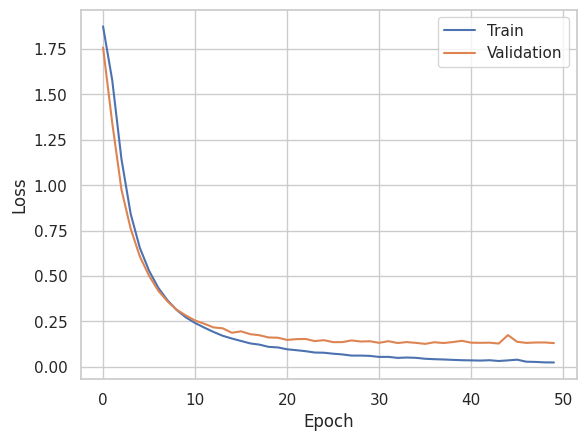

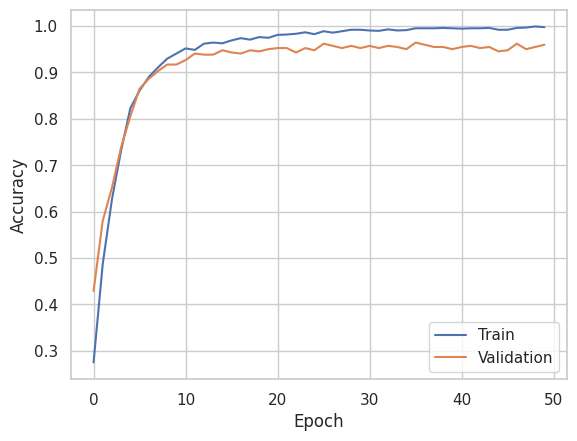

In [ ]:
import torch
import matplotlib.pyplot as plt

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 50

train_losses = []
val_losses = []

train_accs = []
val_accs = []

best_val_acc = 0

for epoch in range(epochs):


    # Training

    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for xb, yb in train_loader:

        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()

        logits = model(xb)

        loss = criterion(logits, yb)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        preds = torch.argmax(logits, dim=1)
        train_correct += (preds == yb).sum().item()
        train_total += yb.size(0)

    train_loss /= len(train_loader)
    train_acc = train_correct / train_total


    # Validation

    model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for xb, yb in val_loader:

            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits = model(xb)

            loss = criterion(logits, yb)

            val_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == yb).sum().item()
            val_total += yb.size(0)

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "ffn_best.pt")

# Plot Loss
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Plot Accuracy
plt.plot(train_accs, label="Train")
plt.plot(val_accs, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

**1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1**

logits = model(xb) : forwrd pass

loss.backward(): computes gradients for backpropagation
optimizer.step() :updates the weights using gradient descent.

**2. Looking at your curves, is the model overfitting, underfitting, or well-fitted?**

since the accuracy of the train and validation loss is quite close the model is well fitted

**3. Why do we call optimizer.zero_grad() every batch?**

It clears the old gradients before computing new ones. this reduces accumulation across batches which leads to incorrect parameter updates.




In [ ]:
def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):

    # Create model
    model = FeedForwardNet(
        input_dim=X_train.shape[1],
        hidden_sizes=hidden_sizes,
        dropout=dropout
    ).to(DEVICE)

    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # History
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    # Training loop
    for epoch in range(epochs):

        #Training
        model.train()

        running_train_loss = 0
        train_correct = 0
        train_total = 0

        for xb, yb in train_loader:

            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()

            logits = model(xb)

            loss = criterion(logits, yb)

            loss.backward()

            optimizer.step()

            running_train_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            train_correct += (preds == yb).sum().item()
            train_total += yb.size(0)

        train_loss = running_train_loss / len(train_loader)
        train_acc = train_correct / train_total

        #Validation
        model.eval()

        running_val_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for xb, yb in val_loader:

                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)

                logits = model(xb)

                loss = criterion(logits, yb)

                running_val_loss += loss.item()

                preds = torch.argmax(logits, dim=1)
                val_correct += (preds == yb).sum().item()
                val_total += yb.size(0)

        val_loss = running_val_loss / len(val_loader)
        val_acc = val_correct / val_total

        # Save history
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

    # Return history
    history = {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "train_acc": train_accs,
        "val_acc": val_accs
    }

    return history

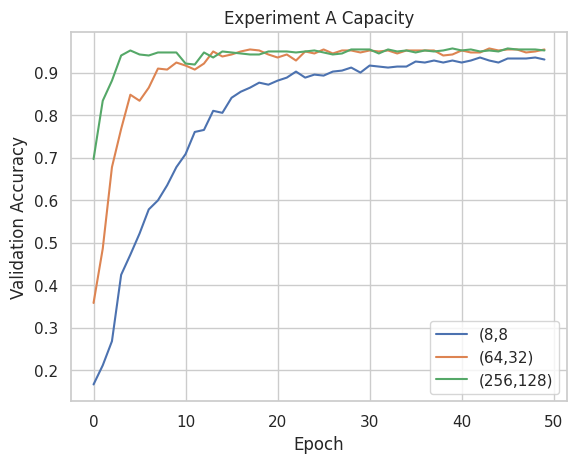

In [ ]:
#capacity changes

small = run_experiment(hidden_sizes=(8,8))
default = run_experiment(hidden_sizes=(64,32))
large = run_experiment(hidden_sizes=(256,128))

plt.plot(small["val_acc"], label="(8,8")
plt.plot(default["val_acc"], label="(64,32)")
plt.plot(large["val_acc"], label="(256,128)")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Experiment A Capacity")
plt.legend()
plt.show()



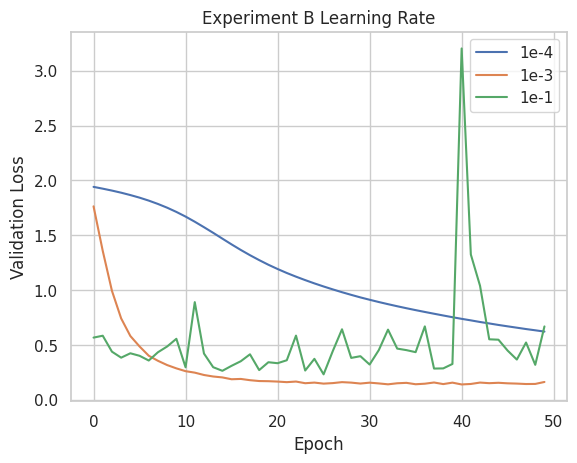

In [ ]:
lr1 = run_experiment(lr=1e-4)
lr2 = run_experiment(lr=1e-3)
lr3 = run_experiment(lr=1e-1)

plt.plot(lr1["val_loss"], label="1e-4")
plt.plot(lr2["val_loss"], label="1e-3")
plt.plot(lr3["val_loss"], label="1e-1")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Experiment B Learning Rate")
plt.legend()
plt.show()

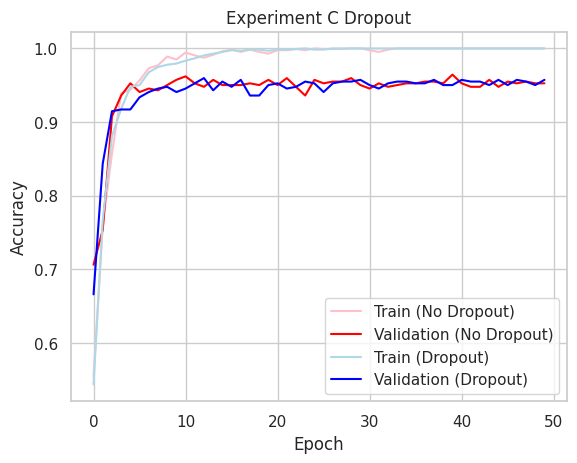

In [ ]:
no_dropout = run_experiment(
    hidden_sizes=(256,128),
    dropout=0.0
)

dropout = run_experiment(
    hidden_sizes=(256,128),
    dropout=0.3
)

plt.plot(no_dropout["train_acc"], label="Train (No Dropout)", color="pink")
plt.plot(no_dropout["val_acc"], label="Validation (No Dropout)", color="red")

plt.plot(dropout["train_acc"], label="Train (Dropout)", color="lightblue")
plt.plot(dropout["val_acc"], label="Validation (Dropout)", color="blue")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Experiment C Dropout")
plt.legend()
plt.show()

**1. Capacity:**

The largest network may achieve the highest training accuracy, but it may not have the best validation accuracy due to overfitting.

**2. Learning Rate:**

Yes. A small learning rate learns slowly, a moderate learning rate converges well, and a very large learning rate can make the loss unstable.

**3. Regularisation:**

Dropout reduces the gap between the training and validation accuracy by randomly turning off some neurons during training. This helps the model generalise better and reduces overfitting.

Test Accuracy: 0.9408983451536643
Test Macro-F1: 0.9383826749460178
              precision    recall  f1-score   support

           0       0.94      0.91      0.92        54
           1       0.83      0.84      0.84        58
           2       0.99      0.99      0.99        70
           3       1.00      0.97      0.98        60
           4       0.98      1.00      0.99        65
           5       0.88      0.88      0.88        58
           6       0.95      0.98      0.97        58

    accuracy                           0.94       423
   macro avg       0.94      0.94      0.94       423
weighted avg       0.94      0.94      0.94       423



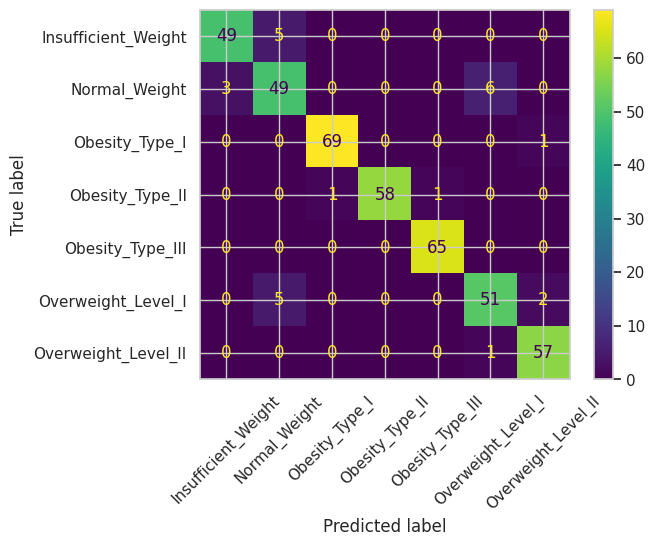

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt

# Load the best model
model.load_state_dict(torch.load("ffn_best.pt"))
model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for xb, yb in test_loader:

        xb = xb.to(DEVICE)

        logits = model(xb)

        preds = torch.argmax(logits, dim=1)

        y_true.extend(yb.numpy())
        y_pred.extend(preds.cpu().numpy())

# Accuracy
accuracy = accuracy_score(y_true, y_pred)

# Macro F1
macro_f1 = f1_score(y_true, y_pred, average="macro")

print("Test Accuracy:", accuracy)
print("Test Macro-F1:", macro_f1)

# Classification Report
print(classification_report(y_true, y_pred))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=label_encoder.classes_,
    xticks_rotation=45
)

plt.show()

In [ ]:
comparison = pd.DataFrame({
    "Model": ["K-Nearest Neighbors (K=2)", "Neural Network"],
    "Test Accuracy": [0.8298, accuracy],
    "Test Macro-F1": [0.8145, macro_f1],
    "Training Time": ["0.7s", "0s"],
    "Parameters": ["K=2", total_params]
})
comparison



,Model,Test Accuracy,Test Macro-F1,Training Time,Parameters
0,K-Nearest Neighbors (K=2),0.829800,0.814500,0.7s,K=2
1,Neural Network,0.940898,0.938383,0s,3655


**1. Which obesity levels does the network still confuse, and are they the same ones your Lab 2 classifier confused?**

There network still confuses the normal weight and insufficient weight, however there confusion greately reduced.

**2. Who wins the showdown,the neural network or the classical model? Was the extra effort of deep learning worth it on this dataset? When would it be?**

te neural network won with higher test accracy and micro-F1 test as compared to the classical model.


**Reflection**

1.The black box, opened:
 loss.backward() calculates  the gradients for all the weights. optimizer.step() then uses those gradients to update the weights so the model performs better.


2. Hyperparameters:
I would choose the learning rate because it controls how fast or slow the model learns, and it has a big impact on the final performance.

3. overfitting
The biggest gap was with the largest network. Adding dropout reduced the gap the most by helping the model generalise better.

4. Looking ahead:
A plain MLP treats every pixel separately, so it cannot capture nearby patterns in an image. A better architecture should be able to learn local features, like a CNN.
